# Supplementary Figure SR6 — unique diseases vs unique TAs per colocalisation cluster

Reviewer 1, minor comment 9: *"Line 175: It's not obvious from the text what the 'two counts' here
are. The data underlying the statistic should be considered as a supplementary figure."*

The statistic is Spearman $\rho = 0.81$, $P < 1 \times 10^{-16}$, between the number of unique
diseases per colocalisation cluster and the number of unique therapeutic areas (TAs) per cluster
(`sections/results/04_variant_pleiotropy.tex`, para 1).

**Source table.** `data/intermediate_files/cluster_disease_ta_counts-r1.csv`, one row per cluster,
built by `00_build_cluster_table-r1.py`. No cluster-level table was present on disk, so that script
re-derives it from the unchanged release inputs using the exact code of
`chapters/02-analysis/04-variant-level-ps/02_clustering_analysis.ipynb` (cells 5-6 clustering,
cell 13 `uniqueTraitsInCluster`, cells 18-19 `clusterNumberTherapeuticAreas`), reimplemented without
Spark. Connected components are order-independent, so the cluster partition is identical.

**Two trait columns.** The table carries per-cluster counts on both:

| Suffix | Trait column | Role |
|---|---|---|
| `_raw` | `traitFromSourceMappedIds` | What the clustering notebook reads. Reproduces the published numbers, so it is the control for this table's lineage. |
| `_resolved` | `diseaseIds` | The ontology-resolved mapping used by every other analysis in the repo. **SR6 is drawn from these.** |

Step 1 controls the `_raw` counts against the manuscript; step 2 documents why `_resolved` is the
right column and what moves; step 3 plots `_resolved`. Nothing is recomputed here.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats

TABLE = "../../../data/intermediate_files/cluster_disease_ta_counts-r1.csv"
clusters = pd.read_csv(TABLE)

raw_dis, raw_ta = clusters["uniqueTraitsInCluster_raw"], clusters["clusterNumberTherapeuticAreas_raw"]
dis, tas = clusters["uniqueTraitsInCluster_resolved"], clusters["clusterNumberTherapeuticAreas_resolved"]
clusters.head()

,cluster_id,lead_study_locus_id,cluster_size,uniqueTraitsInCluster_raw,clusterNumberTherapeuticAreas_raw,uniqueTraitsInCluster_resolved,clusterNumberTherapeuticAreas_resolved
0,0,6765288622bb74993c28aed49c82427a,80,37,6,37,6
1,1,a646ee6e67e10096214c7fd27707a435,27,5,1,5,1
2,2,fbca888973fb6892b29e711d6c24d442,50,20,5,20,5
3,3,689ff8b8033176c49fcb6f5cc07ae5dd,2,2,2,2,2
4,4,0c291e9253c39a7a0aeda93784455da2,93,36,7,36,7


## Step 1 — control on the `_raw` counts

Hard asserts against every number the manuscript states. These use `traitFromSourceMappedIds`, the
column the clustering notebook actually reads, so passing them proves this table has the same
lineage as the published figures — if they failed, everything below would be plotting a different
table from the one the text describes.

In [2]:
def control(label, got, want, tol=0.0):
    ok = abs(got - want) <= tol
    print(f"{'PASS' if ok else 'FAIL'}  {label}: got {got!r}, want {want!r}")
    assert ok, label
    return got


n = control("n clusters", len(clusters), 20041)
control("total CSs clustered", int(clusters["cluster_size"].sum()), 70618)
control("clusters of size >1", int((clusters["cluster_size"] > 1).sum()), 8136)

control("clusters with >1 disease", int((raw_dis > 1).sum()), 6678)
control("  ... fraction", float((raw_dis > 1).mean()), 0.3332169053440447, 1e-15)
control("disease count max", int(raw_dis.max()), 122)
control("disease count mean", float(raw_dis.mean()), 2.156080035926351, 1e-12)

control("clusters with >1 TA", int((raw_ta > 1).sum()), 4536)
control("  ... fraction", float((raw_ta > 1).mean()), 0.22633601117708696, 1e-15)
control("TA count max", int(raw_ta.max()), 20)
control("TA count mean", float(raw_ta.mean()), 1.4024749264008782, 1e-12)

raw_rho, raw_p = stats.spearmanr(raw_dis, raw_ta)
control("Spearman rho", float(raw_rho), 0.8071208888491556, 1e-12)
control("P < 1e-16", int(raw_p < 1e-16), 1)

print("\nAll published numbers reproduce to full precision.")

PASS  n clusters: got 20041, want 20041
PASS  total CSs clustered: got 70618, want 70618
PASS  clusters of size >1: got 8136, want 8136
PASS  clusters with >1 disease: got 6678, want 6678
PASS    ... fraction: got 0.3332169053440447, want 0.3332169053440447
PASS  disease count max: got 122, want 122
PASS  disease count mean: got 2.156080035926351, want 2.156080035926351
PASS  clusters with >1 TA: got 4536, want 4536
PASS    ... fraction: got 0.22633601117708696, want 0.22633601117708696
PASS  TA count max: got 20, want 20
PASS  TA count mean: got 1.4024749264008782, want 1.4024749264008782
PASS  Spearman rho: got 0.8071208888491556, want 0.8071208888491556
PASS  P < 1e-16: got 1, want 1

All published numbers reproduce to full precision.


## Step 2 — why the figure uses `diseaseIds` instead

`traitFromSourceMappedIds` is the raw curator-supplied mapping. `diseaseIds` is the
ontology-resolved mapping, and in `qualifying_credible_sets` it equals the study index's
`diseaseIds` for all 70,618 CSs. The two agree on 69,962 CSs (99.07%) and differ on 656.

Every other analysis in the repo uses `diseaseIds` — variant-level `uniqueDiseases`
(`01_variant_level_pleiotropy.ipynb` cell 7), gene-level gPS
(`05-gene-level-ps/01_gene_level_pleiotropy.ipynb`), `mappedTherapeuticAreas`
(`01-data-preparation/04_qualifying_dataset_generation.ipynb` cell 8), and all the enrichment work.
`traitFromSourceMappedIds` appears only in the clustering code path, copy-pasted across four files.
So vPS and lead\_vPS were being counted on different columns, which was not deliberate.

The consequence is concrete: 26 of the 1,425 distinct raw ids have no row in `disease.parquet` at
all — retired EFO ids (`EFO_0000516` glaucoma, `EFO_0003761`, `EFO_0000493`, `EFO_0000352`),
Orphanet ids Open Targets never ingested (`Orphanet_797` sarcoidosis, `Orphanet_34533`), two HP
terms, plus `HANCESTRO_0014` (an *ancestry* term) and the literal string `gastric adenocarcinoma`.
Cell 18's UDF drops any id missing from the lookup (`lookup_dict.get(efo_id, None)` then
`if area is not None`), so those clusters end up with an **empty** TA array and `f.size` = 0 — the
`"other"` fallback cannot rescue them because it is applied when *building* the lookup, not when
querying it. Open Targets had already remapped all 26 to live MONDO terms in `diseaseIds`.

In [3]:
zero_raw = int((raw_ta == 0).sum())
zero_res = int((tas == 0).sum())
print(f"clusters with 0 TAs  --  raw: {zero_raw} ({zero_raw / n:.2%})   resolved: {zero_res}")
print("disease counts of the zero-TA raw clusters:", sorted(raw_dis[raw_ta == 0].unique()))
print("clusters with 0 diseases (either column):", int((raw_dis == 0).sum()), int((dis == 0).sum()))

clusters with 0 TAs  --  raw: 33 (0.16%)   resolved: 0
disease counts of the zero-TA raw clusters: [np.int64(1)]
clusters with 0 diseases (either column): 0 0


In [4]:
def profile(d, t):
    rho, p = stats.spearmanr(d, t)
    return {
        "clusters": len(d),
        "clusters >1 disease": int((d > 1).sum()),
        "  as pct": f"{(d > 1).mean():.0%}",
        "diseases min-max": f"{int(d.min())}-{int(d.max())}",
        "diseases mean": round(float(d.mean()), 4),
        "clusters >1 TA": int((t > 1).sum()),
        "  as pct ": f"{(t > 1).mean():.0%}",
        "TAs min-max": f"{int(t.min())}-{int(t.max())}",
        "TAs mean": round(float(t.mean()), 4),
        "Spearman rho": round(float(rho), 6),
        "rho to 2 dp": round(float(rho), 2),
        "at (1 disease, 1 TA)": int(((d == 1) & (t == 1)).sum()),
    }


comparison = pd.DataFrame(
    {
        "raw (published)": profile(raw_dis, raw_ta),
        "resolved (plotted)": profile(dis, tas),
    }
)
comparison.to_csv("../../../data/intermediate_files/cluster_disease_ta_column_comparison-r1.csv")
print(comparison.to_string())

                     raw (published) resolved (plotted)
clusters                       20041              20041
clusters >1 disease             6678               6617
  as pct                         33%                33%
diseases min-max               1-122              1-120
diseases mean                 2.1561             2.1415
clusters >1 TA                  4536               4539
  as pct                         23%                23%
TAs min-max                     0-20               1-20
TAs mean                      1.4025             1.4046
Spearman rho                0.807121           0.813043
rho to 2 dp                     0.81               0.81
at (1 disease, 1 TA)           13330              13424


Switching columns removes the zero-TA clusters entirely, so the TA range becomes 1--20 exactly as
the manuscript already states, and $\rho$ still rounds to 0.81. Three published numbers move and
need editing in `sections/results/04_variant_pleiotropy.tex` lines 10--12:
**6,678 → 6,617**, **range 1--122 → 1--120**, **mean 2.16 → 2.14**. Both percentages (33%, 23%) and
the TA mean (1.40) are unchanged, as is every conclusion drawn from the statistic.

## Step 3 — the figure

**Overplotting.** Both counts are small integers over 20,041 clusters, so a naive scatter is a solid
block at the origin. Every cluster is plotted — nothing is subsampled and no jitter is applied.
Instead the 20,041 clusters collapse onto a small number of distinct integer coordinates, and each
point is drawn once with **marker area proportional to $\sqrt{n}$** (equivalently, marker radius
$\propto n^{1/4}$), where $n$ is the number of clusters at that coordinate. Area $\propto n$ was
rejected: the modal point holds 13,424 clusters and would have swamped the panel. Points are drawn
with `alpha=0.75` and a thin white edge so overlapping markers stay separable, and a size key gives
the count-to-area mapping.

In [5]:
counts = (
    clusters.groupby(["uniqueTraitsInCluster_resolved", "clusterNumberTherapeuticAreas_resolved"])
    .size()
    .rename("n_clusters")
    .reset_index()
    .rename(
        columns={
            "uniqueTraitsInCluster_resolved": "diseases",
            "clusterNumberTherapeuticAreas_resolved": "tas",
        }
    )
)
assert counts["n_clusters"].sum() == n
rho, pval = stats.spearmanr(dis, tas)
modal = int(counts["n_clusters"].max())
print("distinct coordinates:", len(counts))
print(
    "clusters at (1 disease, 1 TA):", int(counts.loc[(counts.diseases == 1) & (counts.tas == 1), "n_clusters"].iloc[0])
)
print(f"Spearman rho = {rho:.6f}   P = {pval:.3e}")
counts.sort_values("n_clusters", ascending=False).head(10)

distinct coordinates: 219
clusters at (1 disease, 1 TA): 13424
Spearman rho = 0.813043   P = 0.000e+00


,diseases,tas,n_clusters
0,1,1,13424
2,2,2,1547
1,2,1,1524
4,3,2,688
5,3,3,311
3,3,1,297
7,4,2,297
8,4,3,171
11,5,2,132
12,5,3,123


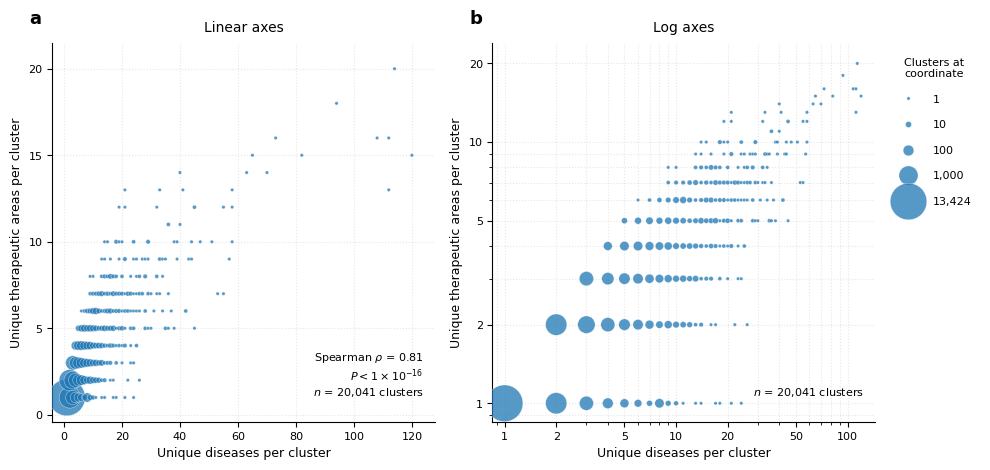

saved figure_sr6-r1.pdf


In [6]:
BLUE = "#1f77b4"
SIZE_SCALE = 6.0  # marker area in pt^2 = SIZE_SCALE * sqrt(n_clusters)


def marker_area(n_clusters):
    return SIZE_SCALE * np.sqrt(n_clusters)


def draw(ax, sub, logscale):
    ax.scatter(
        sub["diseases"],
        sub["tas"],
        s=marker_area(sub["n_clusters"]),
        color=BLUE,
        alpha=0.75,
        linewidths=0.3,
        edgecolors="white",
        zorder=10,
    )
    ax.set_xlabel("Unique diseases per cluster", fontsize=9)
    ax.set_ylabel("Unique therapeutic areas per cluster", fontsize=9)
    ax.grid(True, which="both", ls=":", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)
    if logscale:
        ax.set_xscale("log")
        ax.set_yscale("log")
        for axis, ticks in ((ax.xaxis, [1, 2, 5, 10, 20, 50, 100]), (ax.yaxis, [1, 2, 5, 10, 20])):
            axis.set_major_formatter(plt.ScalarFormatter())
            axis.set_minor_formatter(plt.NullFormatter())
            axis.set_ticks(ticks)
        ax.set_xlim(0.85, 145)
        ax.set_ylim(0.85, 24)
    else:
        ax.set_xticks([0, 20, 40, 60, 80, 100, 120])
        ax.set_yticks([0, 5, 10, 15, 20])
        ax.set_xlim(-4, 128)
        ax.set_ylim(-0.4, 21.5)


fig, axes = plt.subplots(1, 2, figsize=(10, 4.8))

draw(axes[0], counts, logscale=False)
axes[0].set_title("Linear axes", fontsize=10, pad=8)
axes[0].text(
    0.97,
    0.06,
    f"Spearman $\\rho$ = {rho:.2f}\n$P < 1 \\times 10^{{-16}}$\n$n$ = {n:,} clusters",
    transform=axes[0].transAxes,
    fontsize=8,
    ha="right",
    va="bottom",
)

draw(axes[1], counts, logscale=True)
axes[1].set_title("Log axes", fontsize=10, pad=8)
axes[1].text(
    0.97,
    0.06,
    f"$n$ = {n:,} clusters",
    transform=axes[1].transAxes,
    fontsize=8,
    ha="right",
    va="bottom",
)

for ax, tag in zip(axes, ["a", "b"]):
    ax.text(-0.06, 1.04, tag, transform=ax.transAxes, fontsize=13, fontweight="bold", va="bottom")

key_counts = [1, 10, 100, 1000, modal]
handles = [
    Line2D(
        [],
        [],
        marker="o",
        ls="none",
        color=BLUE,
        alpha=0.75,
        markeredgecolor="white",
        markeredgewidth=0.3,
        markersize=np.sqrt(marker_area(k)),
        label=f"{k:,}",
    )
    for k in key_counts
]
axes[1].legend(
    handles=handles,
    title="Clusters at\ncoordinate",
    frameon=False,
    fontsize=8,
    title_fontsize=8,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    labelspacing=1.4,
    borderpad=0.8,
    handletextpad=1.2,
)

plt.tight_layout()
fig.savefig("figure_sr6-r1.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("saved figure_sr6-r1.pdf")

Both counts have a minimum of 1 on the resolved column, so both panels plot all 20,041 clusters and
there are no zeros to drop from the log panel.

## Exact numbers plotted

In [7]:
summary = pd.DataFrame(
    [
        ("clusters plotted (both panels)", n),
        ("distinct coordinates", len(counts)),
        ("clusters at (1 disease, 1 TA)", int(((dis == 1) & (tas == 1)).sum())),
        ("clusters with 0 TAs", int((tas == 0).sum())),
        ("unique diseases: min / max", f"{int(dis.min())} / {int(dis.max())}"),
        ("unique diseases: mean", round(float(dis.mean()), 4)),
        ("unique TAs: min / max", f"{int(tas.min())} / {int(tas.max())}"),
        ("unique TAs: mean", round(float(tas.mean()), 4)),
        ("clusters with >1 disease", int((dis > 1).sum())),
        ("clusters with >1 TA", int((tas > 1).sum())),
        ("Spearman rho", round(float(rho), 6)),
        ("Spearman P", f"{pval:.3e}"),
    ],
    columns=["quantity", "value"],
)
summary.to_csv("../../../data/intermediate_files/cluster_disease_ta_figure_numbers-r1.csv", index=False)
print(summary.to_string(index=False))

                      quantity     value
clusters plotted (both panels)     20041
          distinct coordinates       219
 clusters at (1 disease, 1 TA)     13424
           clusters with 0 TAs         0
    unique diseases: min / max   1 / 120
         unique diseases: mean    2.1415
         unique TAs: min / max    1 / 20
              unique TAs: mean    1.4046
      clusters with >1 disease      6617
           clusters with >1 TA      4539
                  Spearman rho  0.813043
                    Spearman P 0.000e+00


In [8]:
top = counts.sort_values("n_clusters", ascending=False).head(15).reset_index(drop=True)
top["pct_of_clusters"] = (top["n_clusters"] / n * 100).round(2)
print("15 most populated coordinates:")
print(top.to_string(index=False))
print(
    f"\ntop 10 coordinates cover {top.head(10)['n_clusters'].sum():,} clusters "
    f"({top.head(10)['n_clusters'].sum() / n:.1%})"
)

15 most populated coordinates:
 diseases  tas  n_clusters  pct_of_clusters
        1    1       13424            66.98
        2    2        1547             7.72
        2    1        1524             7.60
        3    2         688             3.43
        3    3         311             1.55
        3    1         297             1.48
        4    2         297             1.48
        4    3         171             0.85
        5    2         132             0.66
        5    3         123             0.61
        4    1          98             0.49
        6    2          86             0.43
        6    3          85             0.42
        6    4          59             0.29
        5    4          58             0.29

top 10 coordinates cover 18,514 clusters (92.4%)
